Tickereitä löytyi: 504
Aloitetaan, tickereitä: 504 käsitellään: 504
Käsitelty 50 / 504
Käsitelty 100 / 504
Käsitelty 150 / 504
Käsitelty 200 / 504


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}


Käsitelty 250 / 504


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}


Käsitelty 300 / 504
Käsitelty 350 / 504
Käsitelty 400 / 504
Käsitelty 450 / 504


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}


Käsitelty 500 / 504
Tallennettu: results.csv
  ticker         pb  roe_2y_avg
0   MSFT   9.813268    0.312377
1   NVDA  37.781070    0.805588
2   AAPL  51.967537    1.582532
3   AMZN   7.151155    0.178947
4   META   8.483501    0.298352
5   AVGO   5.825130    0.185792
6  GOOGL  10.257235    0.284193
7   TSLA  18.497381    0.168629
8  BRK-B   0.001028    0.154243
9   GOOG  10.275185    0.284193

TOP 50 LONG:
ticker  roe_%   pb  score
   APA  61.38 1.50   75.0
  CHTR  36.86 1.78  145.0
   DVN  25.51 1.47  177.0
 CMCSA  18.77 1.07  190.0
  ACGL  22.46 1.52  207.0
  BALL  43.57 2.75  221.0
   DAL  32.05 2.49  227.0
   EOG  24.42 1.88  234.0
    BG  16.07 1.23  240.0
   PHM  25.25 2.01  243.0
    EG  14.48 0.91  246.0
   EMN  16.02 1.36  252.0
   MOH  26.05 2.21  255.0
  APTV  22.88 2.07  258.0
  FANG  13.88 1.08  262.0
   AFL  21.02 2.00  267.0
   AES  28.04 2.64  269.0
    GL  20.91 2.00  270.0
   OMC  36.89 3.31  277.0
   GIS  25.76 2.55  278.0
   COP  18.25 1.86  280.0
   UAL  26.46 2.6

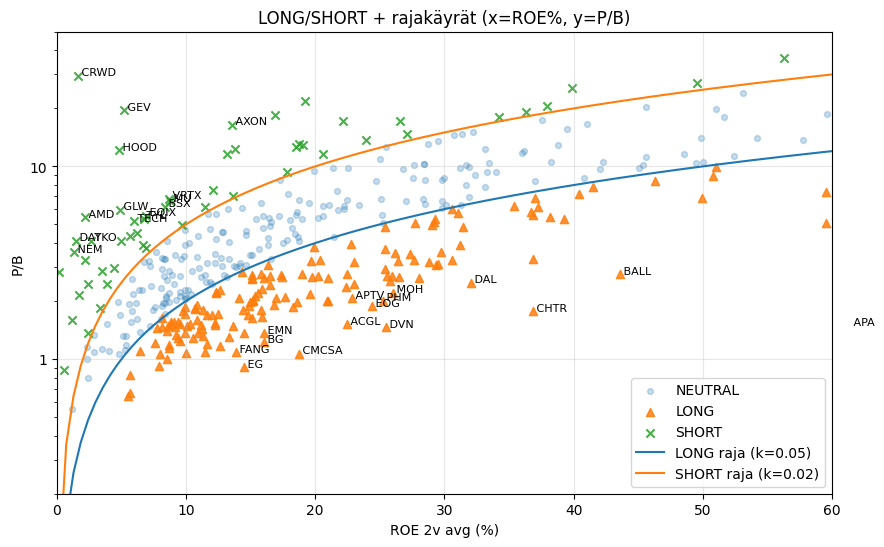

LONG: 158 NEUTRAL: 222 SHORT: 55


In [3]:
import pandas as pd
import yfinance as yf
import re
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

SLEEP_S = 0.05
PROGRESS_STEP = 50

TOP_N = 50
ANNOTATE_N = 20

USE_LOGX = True
ZOOM_XLIM = (0.2, 15)
ZOOM_YLIM = (0, 60)
POLKU = "S&P500 company.txt"

TICKER_RE = re.compile(r"^[A-Z]{1,5}(\.[A-Z])?$")

def seuraava_ei_tyhja(Tiedosto):
    Rivi = Tiedosto.readline()
    while len(Rivi) > 0:
        Rivi = Rivi.strip()
        if Rivi != "":
            return Rivi
        Rivi = Tiedosto.readline()
    return ""  # EOF
    
def poimi_tickerit(polku):
    
    Tiedosto = open(polku, "r", encoding="UTF-8")

    _ = seuraava_ei_tyhja(Tiedosto)  # Company
    _ = seuraava_ei_tyhja(Tiedosto)  # Symbol

    tickers = []

    while True:
        yritys = seuraava_ei_tyhja(Tiedosto)
        if yritys == "":
            break

        symboli = seuraava_ei_tyhja(Tiedosto)
        if symboli == "":
            break

        if TICKER_RE.match(symboli):
            tickers.append(symboli.replace(".", "-"))

    Tiedosto.close()
    return tickers

#tickers = poimi_tickerit(POLKU)
#print("Tickereitä löytyi:", len(tickers))


def pb_arvo(t: yf.Ticker):
    try:
        
        info = t.info or {}
        pb = info.get("priceToBook")
        if pb is None:
            return None
        if pb <= 0:
            return None
        return float(pb)
    except Exception:
        return None


def roe_avg_2y(t):
    try:
        fin = t.financials  #Tuloslaskelma
        bs = t.balance_sheet  #Tase
        
        net_income = fin.loc["Net Income"]

        # valitse equity-rivi näistä 
        if "Total Stockholder Equity" in bs.index:
            equity = bs.loc["Total Stockholder Equity"]
        elif "Stockholders Equity" in bs.index:
            equity = bs.loc["Stockholders Equity"]
        elif "Common Stock Equity" in bs.index:
            equity = bs.loc["Common Stock Equity"]
        elif "Total Equity Gross Minority Interest" in bs.index:
            equity = bs.loc["Total Equity Gross Minority Interest"]
        else:
            return None

        # ota 2 ensimmäistä yhteistä vuotta (helpoin varma tapa)
        vuodet = []
        for c in net_income.index:
            if c in equity.index:
                vuodet.append(c)
            if len(vuodet) == 2:
                break

        if len(vuodet) < 2:
            return None

        roe1 = float(net_income[vuodet[0]]) / float(equity[vuodet[0]])
        roe2 = float(net_income[vuodet[1]]) / float(equity[vuodet[1]])
        return (roe1 + roe2) / 2

    except Exception:
        return None

def hae_mittarit(tickerit, n=None, sleep_s=0.05, progress_step=50):
    rows = []
    total = len(tickerit) if n is None else min(n, len(tickerit))
    print("Aloitetaan, tickereitä:", len(tickerit), "käsitellään:", total)

    for i, sym in enumerate(tickerit[:total], start=1):
        t = yf.Ticker(sym)
        pb = pb_arvo(t)
        roe = roe_avg_2y(t)

        rows.append({"ticker": sym, "pb": pb, "roe_2y_avg": roe})

        if sleep_s:
            time.sleep(sleep_s)

        if progress_step and i % progress_step == 0:
            print("Käsitelty", i, "/", total)

    return pd.DataFrame(rows)
    
#df = hae_mittarit(tickers, n=None, sleep_s=0.2, progress_step=50)
#print(df)
def hae_top_short_score(df2, n=20, decimals=2):
    """
    Short = score suurin (eli ROE heikko + PB korkea suhteessa muihin).
    df2 pitää sisältää sarakkeet: ticker, roe_2y_avg, roe_%, pb, score
    """
    d = df2.dropna(subset=["pb", "roe_2y_avg", "roe_%", "score"]).copy()

    short = d.nlargest(n, "score")[["ticker", "roe_%", "pb", "score"]].copy()

    short["roe_%"] = short["roe_%"].round(decimals)
    short["pb"] = short["pb"].round(decimals)
    short["score"] = short["score"].round(decimals)
    return short
    
def laske_score_ja_top(df, top_n=50, pb_min=0.2, pb_max=50, roe_min=0.0, roe_max=2.0):
    #df: DataFrame jossa sarakkeet: ticker, pb, roe_2y_avg"
    #Palauttaa: (df2, top) missä df2 on siivottu+score ja top on top_n lista."
    df2 = df.dropna().copy()

    # siivous (voit muuttaa tai laittaa None/poistaa kokonaan)
    df2 = df2[(df2["pb"] > pb_min) & (df2["pb"] < pb_max)]
    df2 = df2[(df2["roe_2y_avg"] > roe_min) & (df2["roe_2y_avg"] < roe_max)]

    df2["roe_%"] = df2["roe_2y_avg"] * 100

    # yhdistelmäscore: ROE iso hyvä, PB pieni hyvä
    df2["score"] = df2["roe_2y_avg"].rank(ascending=False) + df2["pb"].rank(ascending=True)

    top = df2.sort_values("score").head(top_n)[["ticker", "roe_%", "pb", "score"]]
    return df2, top
    
def tulosta_top(top_df, decimals=2):
    """
    Tulostaa top-listan niin että ROE on ensin ja PB oikealla.
    """
    out = top_df.copy()
    out["roe_%"] = out["roe_%"].round(decimals)
    out["pb"] = out["pb"].round(decimals)
    out["score"] = out["score"].round(decimals)
    print(out.to_string(index=False))

    
def top_roe_div_pb(df2, top_n=50, decimals=2):
    """
    Vaihtoehtoinen ranking: ROE/PB (suurempi parempi)
    """
    d = df2.copy()
    d["roe_div_pb"] = d["roe_2y_avg"] / d["pb"]
    top = d.sort_values("roe_div_pb", ascending=False).head(top_n)[["ticker", "roe_%", "pb", "roe_div_pb"]]
    top = top.copy()
    top["roe_%"] = top["roe_%"].round(decimals)
    top["pb"] = top["pb"].round(decimals)
    top["roe_div_pb"] = top["roe_div_pb"].round(decimals)
    print(top.to_string(index=False))
    return top
    
def piirra_long_short_flip(df2, long_df, short_df, label_long=10, label_short=10, title="P/B vs ROE (Long & Short)"):
    base = df2.dropna(subset=["pb", "roe_%"]).copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(base["roe_%"], base["pb"], alpha=0.2, s=15, label=("Kaikki (" + str(len(base)) + ")"))

    plt.scatter(long_df["roe_%"], long_df["pb"], s=80, edgecolors="black", label=("LONG (" + str(len(long_df)) + ")"))
    plt.scatter(short_df["roe_%"], short_df["pb"], s=80, marker="x", label=("SHORT (" + str(len(short_df)) + ")"))

    for _, r in long_df.head(label_long).iterrows():
        plt.text(float(r["roe_%"]), float(r["pb"]), " " + str(r["ticker"]), fontsize=8)

    for _, r in short_df.head(label_short).iterrows():
        plt.text(float(r["roe_%"]), float(r["pb"]), " " + str(r["ticker"]), fontsize=8)

    plt.xlabel("ROE 2v avg (%)")
    plt.ylabel("P/B")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()

    # P/B usein parempi log-asteikolla
    plt.yscale("log")

    plt.show()

def piirra_long_short_flip_kayra(df2, long_df=None, short_df=None,
                                 title="LONG/SHORT (x=ROE%, y=P/B)",
                                 k_long=0.05, k_short=0.02,
                                 label_long_n=15, label_short_n=15,
                                 logy=True, xlim=None, ylim=None):

    d = df2.dropna(subset=["pb", "roe_2y_avg"]).copy()
    d["roe_%"] = d["roe_2y_avg"] * 100
    d["roe_div_pb"] = d["roe_2y_avg"] / d["pb"]

    d["signal"] = "NEUTRAL"
    d.loc[d["roe_div_pb"] >= k_long, "signal"] = "LONG"
    d.loc[d["roe_div_pb"] <= k_short, "signal"] = "SHORT"

    d_long = d[d["signal"] == "LONG"]
    d_neu = d[d["signal"] == "NEUTRAL"]
    d_short = d[d["signal"] == "SHORT"]

    # x-akseli (ROE%) range, varo nollaa
    x_min = float(d["roe_%"].min())
    x_max = float(d["roe_%"].max())
    if x_min <= 0:
        x_min = 0.1

    xs = np.linspace(x_min, x_max, 300)

    # Raja “käyrät” kun x=ROE% ja y=P/B:
    # ehto: roe/pb = k  =>  pb = roe/k  =>  pb = (roe_%/100) / k = roe_% / (100*k)
    y_long = xs / (100.0 * k_long)
    y_short = xs / (100.0 * k_short)

    plt.figure(figsize=(10, 6))

    # Pisteet (samat markerit kuin sulla)
    plt.scatter(d_neu["roe_%"], d_neu["pb"], marker="o", alpha=0.25, s=18, label="NEUTRAL")
    plt.scatter(d_long["roe_%"], d_long["pb"], marker="^", alpha=0.85, s=35, label="LONG")
    plt.scatter(d_short["roe_%"], d_short["pb"], marker="x", alpha=0.85, s=35, label="SHORT")

    # Käyrät (rajat)
    plt.plot(xs, y_long, label=("LONG raja (k=" + str(k_long) + ")"))
    plt.plot(xs, y_short, label=("SHORT raja (k=" + str(k_short) + ")"))

    # Labelit long-listasta ja short-listasta (jos annetaan)
    if long_df is not None:
        for _, r in long_df.head(label_long_n).iterrows():
            plt.text(float(r["roe_%"]), float(r["pb"]), " " + str(r["ticker"]), fontsize=8)

    if short_df is not None:
        for _, r in short_df.head(label_short_n).iterrows():
            plt.text(float(r["roe_%"]), float(r["pb"]), " " + str(r["ticker"]), fontsize=8)

    plt.xlabel("ROE 2v avg (%)")
    plt.ylabel("P/B")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()

    if logy:
        ax = plt.gca()
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.LogFormatter(10, labelOnlyBase=False))
       

    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.show()

    print("LONG:", len(d_long), "NEUTRAL:", len(d_neu), "SHORT:", len(d_short))


tickers = poimi_tickerit(POLKU)
print("Tickereitä löytyi:", len(tickers))

df = hae_mittarit(tickers, sleep_s=SLEEP_S, progress_step=PROGRESS_STEP)
df.to_csv("results.csv", index=False)
print("Tallennettu: results.csv")
print(df.head(10))

df2, top50 = laske_score_ja_top(df, top_n=TOP_N)

#df2, top50 = laske_score_ja_top(df, top_n=TOP_N)
print("\nTOP 50 LONG:")
tulosta_top(top50, decimals=2)


short20 = hae_top_short_score(df2, n=20, decimals=2)
print("\nTOP 20 SHORT (reverse score):")
print(short20.to_string(index=False))
# Tulokset tiedostoon
with pd.ExcelWriter("results.xlsx") as writer:
    df.to_excel(writer, index=False, sheet_name="kaikki")
    df2.to_excel(writer, index=False, sheet_name="siivottu")
    top50.to_excel(writer, index=False, sheet_name="top_long")
    short20.to_excel(writer, index=False, sheet_name="top_short")

print("Tallennettu: results.xlsx")
# Tallennus loppuu
piirra_long_short_flip_kayra(
    df2,
    long_df=top50,
    short_df=short20,
    title="LONG/SHORT + rajakäyrät (x=ROE%, y=P/B)",
    k_long=0.05,
    k_short=0.02,
    label_long_n=15,
    label_short_n=15,
    logy=True,
    xlim=(0, 60),
    ylim=(0.2, 50)
)